In [1]:
%load_ext skip_cell
%reload_ext skip_cell

In [2]:
THREE_P_MAN = {
    "RLRRLR": [1,  "RLR", "RLR"],
    "LRLLRL": [2,  "LRL", "LRL"],
    "RLRRSR": [3,  "RLR", "RSR"],
    "RLRRSL": [4,  "RLR", "RSL"],
    "LRLLSL": [5,  "LRL", "LSL"],
    "LRLLSR": [6,  "LRL", "LSR"],
    "RSRRLR": [7,  "RSR", "RLR"],
    "LSRRLR": [8,  "LSR", "RLR"],
    "RSLLRL": [9,  "RSL", "LRL"],
    "LSLLRL": [10, "LSL", "LRL"],
    "RSRRSR": [11, "RSR", "RSR"],
    "LSRRSR": [12, "LSR", "RSR"],
    "RSRRSL": [13, "RSR", "RSL"],
    "LSRRSL": [14, "LSR", "RSL"],
    "LSLLSL": [15, "LSL", "LSL"],
    "RSLLSL": [16, "RSL", "LSL"],
    "LSLLSR": [17, "LSL", "LSR"],
    "RSLLSR": [18, "RSL", "LSR"]
}

THREE_P_MAN_ID = ["RLRRLR", "LRLLRL", "RLRRSR", "RLRRSL", "LRLLSL", "LRLLSR", "RSRRLR", "LSRRLR", "RSLLRL", "LSLLRL", "RSRRSR", "LSRRSR", "RSRRSL", "LSRRSL", "LSLLSL", "RSLLSL", "LSLLSR", "RSLLSR"]


In [3]:
from math import pi, cos, sin, radians, degrees

kmax = 1

theta_i = radians(0)
theta_f = radians(180)
alpha_m = radians(45)
alpha_f = radians(90)

pi_c = (1, 0, theta_i)
pm_c = (cos(alpha_m), sin(alpha_m), 0)
pf_c = (cos(alpha_f), sin(alpha_f), theta_f)

TENSORFLOW = True
SKLEARN = False

assert TENSORFLOW ^ SKLEARN, "Choose one and only one library"

## Import the needed libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Read the dataset and split it into train, val and test

In [5]:
data = pd.read_csv('/Users/enrico/Projects/mpdp/3PDS_Circle32_1_1_1.csv', sep='\s+')

features = ['kmax', 'theta_i', 'theta_f', 'alpha_m', 'alpha_f']
target = ['th_m', 'id_man_comb']

X = data[features].values
y = data[target].values

# Split the dataset into training (60%), validation (20%), and test (20%) sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, shuffle=True)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Multi-modal Tensorflow

In [6]:
%%run_if $TENSORFLOW
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [7]:
%%run_if $TENSORFLOW
# Build the neural network model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1024, activation='relu'),
    Dense(32, activation='relu'),
    Dense(2)  # Output layer with 2 outputs for multi-output regression
])
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')


/Users/enrico/Projects/mpdp/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Train

In [8]:
%%run_if $TENSORFLOW
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=10, batch_size=128, verbose=1)


Epoch 1/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 15.4299 - val_loss: 10.9269
Epoch 2/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 10.1820 - val_loss: 9.2233
Epoch 3/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 8.9996 - val_loss: 8.7470
Epoch 4/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 8.2708 - val_loss: 8.0720
Epoch 5/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 7.8321 - val_loss: 7.8717
Epoch 6/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 7.5186 - val_loss: 7.3311
Epoch 7/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 7.2360 - val_loss: 7.4292
Epoch 8/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 7.0404 - val_loss: 7.1196
Epoch 9/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 6.8661 - val_loss: 6.7029
Epoch 10/10
4613/4613 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 6.7963 - val_loss: 7.0684


### Evaluate training

6151/6151 ━━━━━━━━━━━━━━━━━━━━ 3s 463us/step - loss: 7.0547
Test Mean Squared Error: 7.003809452056885


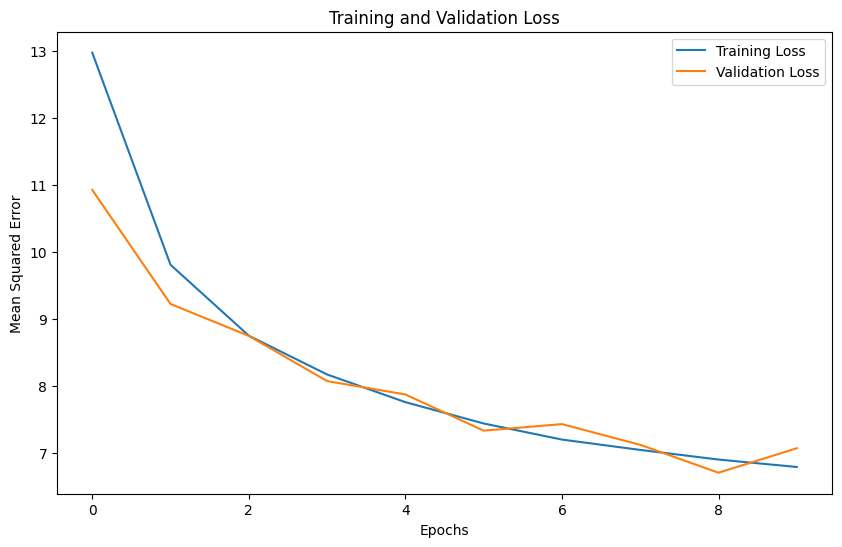

In [9]:
%%run_if $TENSORFLOW

test_loss = model.evaluate(X_test, y_test)
print(f'Test Mean Squared Error: {test_loss}')

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.show()

### Predict

In [10]:
def predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler = None):
    input_data = np.array([[kmax, theta_i, theta_f, alpha_m, alpha_f]])
    if scaler:
        input_data = scaler.transform(input_data)

    [[th, id]] = model.predict(input_data)
    
    print(th, id)

from datetime import datetime
import time

t = datetime.now()
pred, man = predict_id_man_comb(model, kmax, theta_i, theta_f, alpha_m, alpha_f, scaler)
print(f"elapsed {datetime.now() - t}")
if pred is not None and man is not None:
    print(f'The angle of the middle point is: {degrees(pred)}, {pred}')
    print(f'The angle of the middle point is: {THREE_P_MAN_ID[int(man)-1]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
5.53369 9.10367


TypeError: cannot unpack non-iterable NoneType object

## Multi-modal Scikit-Learn

In [ ]:
%%run_if $SKLEARN

from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error

model = MultiOutputRegressor(GradientBoostingRegressor(random_state=0))


### Train

In [ ]:
%%run_if $SKLEARN
model.fit(X_train, y_train)

### Evaluate training

In [ ]:
%%run_if $SKLEARN
y_val_pred = model.predict(X_val)
val_mse = root_mean_squared_error(y_val, y_val_pred)
print(f'Validation Mean Squared Error: {val_mse}')

### Predict

In [ ]:
%%run_if $SKLEARN
[[th, man]] = model.predict([[1, theta_i, theta_f, alpha_m, alpha_f]])
print(th, man)